<a href="https://colab.research.google.com/github/surajgade17/molecular-property-visualizer/blob/main/Molecular_Property_Visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install rdkit

In [54]:
# ---- IMPORTS ----
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

# Silence RDKit warnings
RDLogger.DisableLog('rdApp.*')

In [55]:
# ---- DATASET ----
names = ['Ethanol', 'Aspirin', 'Benzene', 'Caffeine', 'Ibuprofen']

smiles_list = [
    'CCO',
    'CC(=O)Oc1ccccc1C(=O)O',
    'c1ccccc1',
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
]

## COMPUTE PROPERTIES FUNCTION

In [56]:
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)

    # Molecular properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    return mw, logp, hbd, hba

## PROCESS ALL MOLECULES

In [57]:
results = []

for name, smiles in zip(names, smiles_list):
    mw, logp, hbd, hba = compute_properties(smiles)

    results.append({
        'Name': name,
        'SMILES': smiles,
        'Molecular Weight': mw,
        'LogP': logp,
        'HBD': hbd,
        'HBA': hba
    })

# Convert to DataFrame
df = pd.DataFrame(results)

print("Calculated Molecular Properties:")
print(df.round(2))

Calculated Molecular Properties:
        Name                        SMILES  Molecular Weight  LogP  HBD  HBA
0    Ethanol                           CCO             46.07 -0.00    1    1
1    Aspirin         CC(=O)Oc1ccccc1C(=O)O            180.16  1.31    1    3
2    Benzene                      c1ccccc1             78.11  1.69    0    0
3   Caffeine  CN1C=NC2=C1C(=O)N(C(=O)N2C)C            194.19 -1.03    0    3
4  Ibuprofen    CC(C)Cc1ccc(cc1)C(C)C(=O)O            206.28  3.07    1    1


## LIPINSKI RULE CHECK

In [58]:
def lipinski_check(row):
    mw = row['Molecular Weight']
    logp = row['LogP']
    hbd = row['HBD']
    hba = row['HBA']

    violations = 0

    # Rule 1: MW ≤ 500
    if mw > 500:
        violations += 1

    # Rule 2: LogP ≤ 5
    if logp > 5:
        violations += 1

    # Rule 3: HBD ≤ 5
    if hbd > 5:
        violations += 1

    # Rule 4: HBA ≤ 10
    if hba > 10:
        violations += 1

    # Pass if violations ≤ 1
    if violations <= 1:
        result = "PASS"
    else:
        result = "FAIL"

    return violations, result

# Apply Lipinski check to DataFrame
df[['Violations', 'Lipinski Result']] = df.apply(
    lipinski_check,
    axis=1,
    result_type='expand'
)

print("\nLipinski Rule of Five:")
print(
    df[['Name', 'Molecular Weight', 'LogP',
        'HBD', 'HBA', 'Violations', 'Lipinski Result']
    ].round(2)
)


Lipinski Rule of Five:
        Name  Molecular Weight  LogP  HBD  HBA  Violations Lipinski Result
0    Ethanol             46.07 -0.00    1    1           0            PASS
1    Aspirin            180.16  1.31    1    3           0            PASS
2    Benzene             78.11  1.69    0    0           0            PASS
3   Caffeine            194.19 -1.03    0    3           0            PASS
4  Ibuprofen            206.28  3.07    1    1           0            PASS


## VISUALIZE PROPERTIES

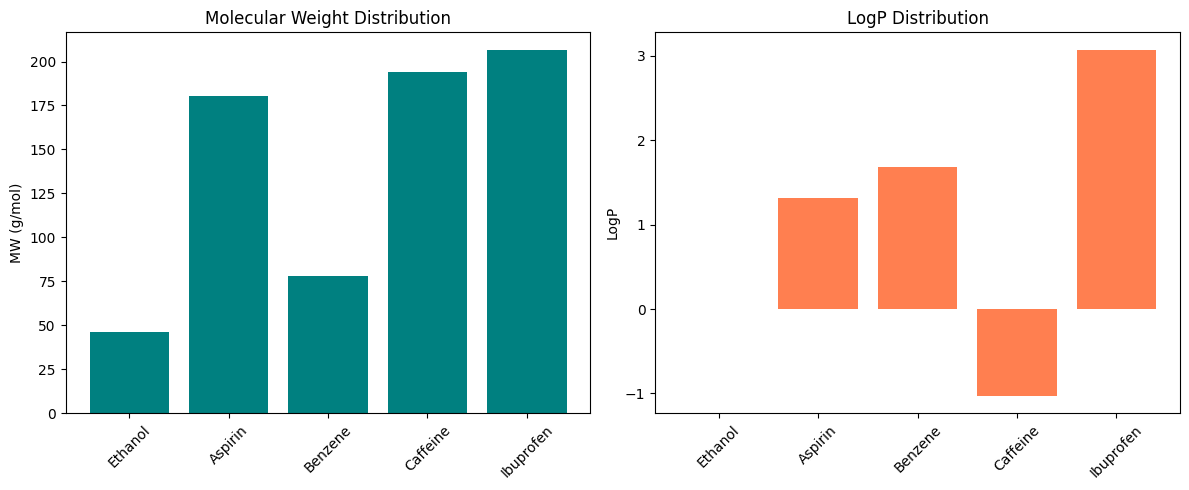

Visualization saved!


In [59]:
# Extract lists for plotting
mw_list = df['Molecular Weight'].tolist()
logp_list = df['LogP'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Molecular Weight
axes[0].bar(names, mw_list, color='teal')
axes[0].set_title('Molecular Weight Distribution')
axes[0].set_ylabel('MW (g/mol)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 — LogP
axes[1].bar(names, logp_list, color='coral')
axes[1].set_title('LogP Distribution')
axes[1].set_ylabel('LogP')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('molecular_properties.png')
plt.show()
print("Visualization saved!")

## SUMMARY

In [60]:
print("\n" + "=" * 60)
print("CHEMINFORMATICS SUMMARY")
print("=" * 60)

print(f"Total molecules analyzed: {len(df)}")

print(
    f"Average Molecular Weight: "
    f"{df['Molecular Weight'].mean():.2f} g/mol"
)

print(
    f"Average LogP: "
    f"{df['LogP'].mean():.2f}"
)

print(
    f"Lipinski PASS: "
    f"{(df['Lipinski Result'] == 'PASS').sum()}"
)

print(
    f"Lipinski FAIL: "
    f"{(df['Lipinski Result'] == 'FAIL').sum()}"
)

print("\nVisualization saved as: molecular_properties.png")
print("Analysis completed successfully!")

print("\n" + "=" * 60)
print("Molecular Property Visualizer — Suraj Gade")
print("GitHub: github.com/surajgade17")
print("=" * 60)


CHEMINFORMATICS SUMMARY
Total molecules analyzed: 5
Average Molecular Weight: 140.96 g/mol
Average LogP: 1.01
Lipinski PASS: 5
Lipinski FAIL: 0

Visualization saved as: molecular_properties.png
Analysis completed successfully!

Molecular Property Visualizer — Suraj Gade
GitHub: github.com/surajgade17
